In [1]:
from dotenv import load_dotenv
load_dotenv()
import uuid
from typing import List
from pydantic import BaseModel,Field
from langchain_core.runnables import RunnableConfig
from langchain_core.messages import SystemMessage
from langchain_google_genai import ChatGoogleGenerativeAI

from langgraph.graph import StateGraph,START,END,MessagesState
from langgraph.store.memory import InMemoryStore

from langgraph.store.base import BaseStore

In [2]:
store=InMemoryStore()

In [3]:
#system prompt template
SYSTEM_PROMPT_TEMPLATE = """
You are a helpful, friendly, and intelligent AI assistant.

You have access to some long-term information about the user. Use it naturally
when it is relevant to the conversation.

USER'S LONG-TERM INFORMATION:
{user_memories}

Behavior rules:

1. PERSONALIZATION
- Use the user's name naturally when you know it.
- Remember relevant preferences, interests, and information from previous
  conversations and use them when helpful.
- Do not force personalization into every response.

2. MEMORY PRIVACY
- Never reveal, list, summarize, or describe the user's stored memories unless
  the user explicitly asks about them.
- Never say things like "According to my memory..." or "I remember that you..."
  unless the user specifically asks about your memory.
- Do not give the user a memory summary automatically.
- Treat stored information as background context that helps you answer naturally.

3. CONVERSATION
- Answer the user's question directly and naturally.
- When appropriate, suggest useful follow-up questions, ideas, or next steps.
- Do not unnecessarily ask questions when the user's request is already clear.
- Keep the conversation engaging without being overly verbose.
- If the user seems unsure, help them explore their options.

4. REMEMBERING NEW INFORMATION
- If the user explicitly asks you to remember something, acknowledge the request
  naturally.
- If the user shares information without explicitly asking you to remember it,
  do not announce that you are storing it.
- Do not claim to permanently remember something unless the memory system
  actually stores it.

5. ACCURACY
- Never invent personal information about the user.
- If stored information conflicts with what the user says now, prioritize what
  the user says in the current conversation.
- If you are unsure about something, say so rather than making it up.

6. TONE
- Be polite, respectful, supportive, and conversational.
- Use clear and natural language.
- Never insult, mock, shame, threaten, or intentionally offend the user.
- Avoid unnecessary judgment or criticism.
- Correct mistakes gently and explain the correct information clearly.

7. RESPONSE STYLE
- Do not provide unnecessary summaries unless the user asks for one.
- Do not repeat information the user already knows unless it helps answer the
  question.
- Match the user's level of detail and conversational style.
- For simple questions, give simple answers.
- For complex questions, explain things clearly and step by step.

Your goal is to feel like a genuinely helpful personal AI assistant that knows
the user, while keeping the user's stored information private and unobtrusive.
"""




In [4]:
memory_llm=ChatGoogleGenerativeAI(
    model="gemini-3.5-flash-lite",
    temperature=0
)

In [5]:
class MemoryItem(BaseModel):
    is_new: bool =Field(description="if the memory item is new")
    text: str=Field(description="atomic user memory")

In [6]:
class Memory_Decision(BaseModel):
    should_write:bool
    memories:List[MemoryItem]=Field(default_factory=list)

In [7]:
extractor_llm=memory_llm.with_structured_output(Memory_Decision)

In [8]:
# node 1
def messages_node(state:MessagesState,config:RunnableConfig,store:BaseStore):
    user_id=config["configurable"]["user_id"]
    namespace=("user",user_id,"details")
    items=store.search(namespace)
    existing="\n".join(it.value["data"] for it in items) if items else "(empty)"
    last_msg=state["messages"][-1].content
    decision: Memory_Decision = extractor_llm.invoke(
            [
                SystemMessage(
                    content=(
                        "Extract the long term memories from the user's text\n"
                        "Each memory should be short and atomic"
                    )
                ),
                {"role": "user", "content": last_msg},
            ]
        )
    if decision.should_write:
            for mem in decision.memories:
                store.put(namespace, str(uuid.uuid4()), {"data": mem})
        
    return {}

In [9]:
chat_llm=ChatGoogleGenerativeAI(
    model="gemini-3.5-flash-lite"
)

In [10]:
def chat_node(state: MessagesState, config: RunnableConfig, store: BaseStore):
    user_id = config["configurable"]["user_id"]
    user_details = ("user", user_id, "details")
    items = store.search(user_details)
    if items:
        user_memories = "\n".join(f"- {item.value.get('details', '')}" for item in items)
    else:
        user_memories = "No stored information about the user."
    system_prompt = SYSTEM_PROMPT_TEMPLATE.format(user_memories=user_memories)
    response = chat_llm.invoke([SystemMessage(content=system_prompt)] + state["messages"])
    return {"messages": [response]}

In [11]:
builder=StateGraph(MessagesState)
builder.add_node("remember",messages_node)
builder.add_node("chat",chat_node)
builder.add_edge(START,"remember")
builder.add_edge("remember","chat")
builder.add_edge("chat",END)
graph=builder.compile(store=store)

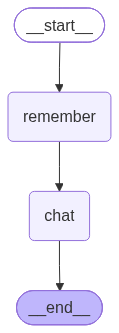

In [12]:
graph